# Model Comparison Experiments

This notebook compares LLM outputs across different models on the same test inputs.

**Goal:** Understand how different models (GPT-5, GPT-OSS-120b, etc.) handle the same prompts.

## Workflow
1. **Configure** - Define models to compare and call types
2. **Run Experiments** - Execute each model on shared test inputs
3. **Calculate Agreement** - Compute pairwise agreement rates
4. **Review Disagreements** - Drill into specific cases where models disagree

## 1. Setup & Configuration

In [1]:
import json
import sys
import os
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Compute repo root from notebook location
# Notebook is at: experiments/compare_models/model_comparison/
REPO_ROOT = Path.cwd().parent.parent.parent.resolve()

# Add project root to path for imports
sys.path.insert(0, str(REPO_ROOT))

# Notebook configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ============================================================================
# CONFIGURATION - Single source of truth
# ============================================================================

# Models to compare
MODELS = [
    'openai/gpt-5',
    'bedrock/openai.gpt-oss-120b-1:0',
]

# Test set configuration (same as self-consistency)
TEST_SET_TAG = 'test_set_2025_11_26'
SAMPLE_SIZE = 100
RANDOM_SEED = 42

# Call type configuration - same as self-consistency notebook
# Paths are relative to REPO_ROOT
CALL_TYPE_CONFIG = {
    'instrument_validation': {
        'prompt': 'paper_data_linking/linkers/general/prompts/validation/system.xml',
        'handler': 'InstrumentValidationHandler',
    },
    'wavelength_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/wavelength_normalization/system.xml',
        'handler': 'WavelengthNormalizationSimpleHandler',
    },
    'physobs_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/physobs_normalization/system.xml',
        'handler': 'PhysObsNormalizationFreeTextV2Handler',
    },
    'mission_selection': {
        'prompt': 'paper_data_linking/linkers/general/prompts/mission_selection/system.xml',
        'handler': 'MissionSelectionHandler',
    },
    'instrument_selection': {
        'prompt': 'paper_data_linking/linkers/general/prompts/instrument_selection/system.xml',
        'handler': 'InstrumentSelectionHandler',
    },
    'detector_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/detector_normalization/system.xml',
        'handler': 'DetectorNormalizationFreeTextV2Handler',
    },
    'time_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/time_normalization/system.xml',
        'handler': 'TimeNormalizationHandler',
    },
    'cadence_normalization': {
        'prompt': 'paper_data_linking/linkers/general/prompts/cadence_normalization/system.xml',
        'handler': 'CadenceNormalizationFreeTextHandler',
    },
    'mission_identification': {
        'prompt': 'paper_data_linking/linkers/general/prompts/mission_identification/system.xml',
        'handler': 'MissionIdentificationHandler',
    },
}

# Derived lists
CALL_TYPES = list(CALL_TYPE_CONFIG.keys())
HANDLER_MAP = {ct: cfg['handler'] for ct, cfg in CALL_TYPE_CONFIG.items()}

# Paths - all relative to notebook location
INPUT_DIR = REPO_ROOT / 'inputs' / 'test_set'
RESULTS_DIR = Path('results')  # Local to notebook

# Response keys for each call type (for comparison)
RESPONSE_KEYS = {
    'detector_normalization': 'detector',
    'cadence_normalization': 'cadences',
    'physobs_normalization': 'physical_observable',
    'wavelength_normalization': 'wavelengths',
    'time_normalization': 'time_ranges',
    'mission_identification': 'mission_indices',
    'mission_selection': 'mission_indices',
    'instrument_selection': 'instrument_indices',
    'instrument_validation': 'validation_result',
}

print(f"Repo Root: {REPO_ROOT}")
print(f"Input Dir: {INPUT_DIR}")
print(f"Test Set: {TEST_SET_TAG}")
print(f"Sample Size: {SAMPLE_SIZE}")
print(f"Models: {len(MODELS)}")
for m in MODELS:
    print(f"  - {m}")
print(f"Call Types: {len(CALL_TYPES)}")

Repo Root: /Users/abuonomo/code/nasa/paper-data-linking
Input Dir: /Users/abuonomo/code/nasa/paper-data-linking/inputs/test_set
Test Set: test_set_2025_11_26
Sample Size: 100
Models: 2
  - openai/gpt-5
  - bedrock/openai.gpt-oss-120b-1:0
Call Types: 9


## 2. Check Input Data

Verify the sampled input files exist (created by self-consistency notebook).

In [2]:
def check_input_files():
    """Check which sampled input files exist and detect source model."""
    status = {}
    for call_type in CALL_TYPES:
        file_path = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}_sampled_{SAMPLE_SIZE}_seed{RANDOM_SEED}.jsonl"
        if file_path.exists():
            with open(file_path) as f:
                lines = [json.loads(line) for line in f]
            # Detect which model generated the original data
            source_models = set(r.get('model_name') for r in lines if r.get('model_name'))
            status[call_type] = {
                'exists': True, 
                'count': len(lines), 
                'path': file_path,
                'source_models': source_models,
                'data': lines  # Keep data for reuse
            }
        else:
            status[call_type] = {'exists': False, 'count': 0, 'path': file_path, 'source_models': set(), 'data': []}
    return status

input_status = check_input_files()

# Display status
df_status = pd.DataFrame([
    {'call_type': ct, 'exists': s['exists'], 'count': s['count'], 'source_model': ', '.join(s['source_models'])}
    for ct, s in input_status.items()
])
print("\nInput File Status:")
print(df_status.to_string(index=False))

# Identify which models' data we already have from the export
all_source_models = set()
for ct, s in input_status.items():
    all_source_models.update(s['source_models'])

print(f"\n📊 Source models in exported data: {all_source_models}")

# Check which of our comparison models are already in the exported data
models_with_existing_data = [m for m in MODELS if m in all_source_models]
models_needing_experiments = [m for m in MODELS if m not in all_source_models]

if models_with_existing_data:
    print(f"✅ Already have data for: {models_with_existing_data}")
    print(f"   (No re-run needed - will use exported data)")
if models_needing_experiments:
    print(f"🔄 Need to run experiments for: {models_needing_experiments}")

missing = [ct for ct, s in input_status.items() if not s['exists']]
if missing:
    print(f"\n⚠️  Missing {len(missing)} input files: {missing}")
    print("\nRun the self-consistency notebook first to export and sample data.")
else:
    print("\n✅ All input files exist!")


Input File Status:
               call_type  exists  count      source_model
   instrument_validation    True    100      openai/gpt-5
wavelength_normalization    True    100      openai/gpt-5
   physobs_normalization    True    100      openai/gpt-5
       mission_selection    True    100      openai/gpt-5
    instrument_selection    True    100      openai/gpt-5
  detector_normalization    True    100      openai/gpt-5
      time_normalization    True    100      openai/gpt-5
   cadence_normalization    True    100      openai/gpt-5
  mission_identification    True    100 openai/gpt-5-mini

📊 Source models in exported data: {'openai/gpt-5-mini', 'openai/gpt-5'}
✅ Already have data for: ['openai/gpt-5']
   (No re-run needed - will use exported data)
🔄 Need to run experiments for: ['bedrock/openai.gpt-oss-120b-1:0']

✅ All input files exist!


## 3. Check Experiment Status

See which model/call-type combinations have been run.

In [3]:
def model_slug(model_name):
    """Convert model name to safe directory slug."""
    return model_name.replace('/', '_').replace(':', '_').replace('.', '_')

def check_experiment_status():
    """
    Check which experiments have been completed.
    
    A model's experiments are "complete" if either:
    1. Results exist in results/{call_type}_{model_slug}/ directory (recursively)
    2. The model was the source of the exported data (no re-run needed)
    """
    status = {}
    for call_type in CALL_TYPES:
        status[call_type] = {}
        source_models = input_status.get(call_type, {}).get('source_models', set())
        
        for model in MODELS:
            # Check if this model's data is already in the export
            if model in source_models:
                status[call_type][model] = 'exported'  # Already have data from export
            else:
                # Check for experiment results (recursive glob for nested dirs)
                slug = model_slug(model)
                exp_dir = RESULTS_DIR / f"{call_type}_{slug}"
                if exp_dir.exists():
                    jsonl_files = list(exp_dir.glob('**/*.jsonl'))  # FIXED: recursive
                    status[call_type][model] = 'run' if jsonl_files else False
                else:
                    status[call_type][model] = False
    return status

exp_status = check_experiment_status()

# Create status matrix with more detail
status_data = []
for call_type in CALL_TYPES:
    row = {'call_type': call_type}
    for model in MODELS:
        s = exp_status[call_type].get(model, False)
        if s == 'exported':
            row[model] = '📦'  # Data from export
        elif s == 'run':
            row[model] = '✅'  # Experiment was run
        else:
            row[model] = '❌'  # Needs to be run
    status_data.append(row)

df_exp_status = pd.DataFrame(status_data)
print("\nExperiment Status:")
print("  📦 = Data from export (no re-run needed)")
print("  ✅ = Experiment completed")
print("  ❌ = Needs to be run")
print()
print(df_exp_status.to_string(index=False))

# Find experiments that actually need to be run
incomplete = []
for call_type in CALL_TYPES:
    for model in MODELS:
        if exp_status[call_type].get(model, False) == False:
            incomplete.append((call_type, model))

if incomplete:
    print(f"\n⚠️  {len(incomplete)} experiments need to be run")
else:
    print(f"\n✅ All experiments have data (exported or run)!")


Experiment Status:
  📦 = Data from export (no re-run needed)
  ✅ = Experiment completed
  ❌ = Needs to be run

               call_type openai/gpt-5 bedrock/openai.gpt-oss-120b-1:0
   instrument_validation            📦                               ❌
wavelength_normalization            📦                               ✅
   physobs_normalization            📦                               ✅
       mission_selection            📦                               ✅
    instrument_selection            📦                               ✅
  detector_normalization            📦                               ✅
      time_normalization            📦                               ✅
   cadence_normalization            📦                               ✅
  mission_identification            ✅                               ✅

⚠️  1 experiments need to be run


## 4. Run Experiments

Run experiments for each model on the shared inputs.

In [4]:
# Import experiment runner
from experiments.compare_models.run_prompt_experiment import run_experiment

def run_model_experiments(
    call_types_to_run: list,
    models_to_run: list,
    force_rerun: bool = False
):
    """
    Run experiments for specified call types and models.
    
    Args:
        call_types_to_run: List of call types to run
        models_to_run: List of models to run
        force_rerun: If True, re-run even if results exist
    """
    results = []
    
    for call_type in call_types_to_run:
        config = CALL_TYPE_CONFIG[call_type]
        input_file = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}_sampled_{SAMPLE_SIZE}_seed{RANDOM_SEED}.jsonl"
        
        # Make prompt path absolute (relative to REPO_ROOT)
        prompt_path = REPO_ROOT / config['prompt']
        
        if not input_file.exists():
            print(f"❌ Input file missing for {call_type}")
            continue
        
        if not prompt_path.exists():
            print(f"❌ Prompt file missing: {prompt_path}")
            continue
        
        for model in models_to_run:
            slug = model_slug(model)
            output_dir = RESULTS_DIR / f"{call_type}_{slug}"
            
            # Check if already complete
            if output_dir.exists() and not force_rerun:
                jsonl_files = list(output_dir.glob('*.jsonl'))
                if jsonl_files:
                    print(f"✅ {call_type} / {model}: Already complete, skipping")
                    continue
            
            print(f"▶️  Running {call_type} / {model}...")
            
            try:
                run_experiment(
                    call_type=call_type,
                    input_file=str(input_file),
                    system_prompt_path=str(prompt_path),  # Use absolute path
                    models=[model],
                    output_dir=str(output_dir),
                    experiment_name=slug,
                    max_cases=SAMPLE_SIZE,
                    handler_class=config['handler'],
                )
                print(f"✅ {call_type} / {model}: Complete")
                results.append({'call_type': call_type, 'model': model, 'status': 'success'})
            except Exception as e:
                print(f"❌ {call_type} / {model}: Failed - {str(e)[:100]}")
                results.append({'call_type': call_type, 'model': model, 'status': 'error', 'error': str(e)})
    
    return results

/Users/abuonomo/code/nasa/paper-data-linking/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# Run incomplete experiments
if incomplete:
    # Group by call type for efficiency
    call_types_needed = list(set(ct for ct, m in incomplete))
    models_needed = list(set(m for ct, m in incomplete))
    
    print(f"Running experiments for {len(call_types_needed)} call types, {len(models_needed)} models")
    print(f"Total experiments: {len(incomplete)}")
    print()
    
    run_results = run_model_experiments(call_types_needed, models_needed)
    
    print("\n" + "="*60)
    print("EXPERIMENT RUN COMPLETE")
    print("="*60)
else:
    print("\u2705 All experiments already completed. Skipping.")

Running experiments for 1 call types, 1 models
Total experiments: 1

▶️  Running instrument_validation / bedrock/openai.gpt-oss-120b-1:0...
Using handler class: InstrumentValidationHandler
Handler: InstrumentValidationHandler
Call type: instrument_validation

Loading system prompt from: /Users/abuonomo/code/nasa/paper-data-linking/paper_data_linking/linkers/general/prompts/validation/system.xml
System prompt length: 6495 characters

Loading input cases from: /Users/abuonomo/code/nasa/paper-data-linking/inputs/test_set/instrument_validation_test_set_2025_11_26_sampled_100_seed42.jsonl
Loaded 100 cases

Output directory: results/instrument_validation_bedrock_openai_gpt-oss-120b-1_0/bedrock_openai_gpt-oss-120b-1_0

Saved system prompt to: results/instrument_validation_bedrock_openai_gpt-oss-120b-1_0/bedrock_openai_gpt-oss-120b-1_0/system_prompt.xml

Running model: bedrock/openai.gpt-oss-120b-1:0



  bedrock/openai.gpt-oss-120b-1:0:   0%|          | 0/100 [00:00<?, ?case/s]23:35:43 - LiteLLM:INFO: utils.py:2929 - 
LiteLLM completion() model= openai.gpt-oss-120b-1:0; provider = bedrock
2026-01-13 23:35:43 - LiteLLM - INFO: 
LiteLLM completion() model= openai.gpt-oss-120b-1:0; provider = bedrock
2026-01-13 23:35:43 - botocore.credentials - INFO: Found credentials in environment variables.
2026-01-13 23:35:46 - httpx - INFO: HTTP Request: POST https://bedrock-runtime.us-west-2.amazonaws.com/model/openai.gpt-oss-120b-1%3A0/converse "HTTP/1.1 200 OK"
23:35:46 - LiteLLM:INFO: utils.py:1212 - Wrapper: Completed Call, calling success_handler
2026-01-13 23:35:46 - LiteLLM - INFO: Wrapper: Completed Call, calling success_handler
23:35:46 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
2026-01-13 23:35:46 - LiteLLM - INFO: selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
23:35:46 - LiteLLM:INFO: cost

    ✓ Case 1: VALID (2167 tokens, $0.000496)


2026-01-13 23:35:49 - httpx - INFO: HTTP Request: POST https://bedrock-runtime.us-west-2.amazonaws.com/model/openai.gpt-oss-120b-1%3A0/converse "HTTP/1.1 200 OK"
23:35:49 - LiteLLM:INFO: utils.py:1212 - Wrapper: Completed Call, calling success_handler
2026-01-13 23:35:49 - LiteLLM - INFO: Wrapper: Completed Call, calling success_handler
23:35:49 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
2026-01-13 23:35:49 - LiteLLM - INFO: selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
23:35:49 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
2026-01-13 23:35:49 - LiteLLM - INFO: selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
                                                                                    23:35:49 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/opena

    ✓ Case 2: VALID (2518 tokens, $0.000731)


...

    ✓ Case 98: VALID (2316 tokens, $0.000617)


2026-01-13 23:40:08 - httpx - INFO: HTTP Request: POST https://bedrock-runtime.us-west-2.amazonaws.com/model/openai.gpt-oss-120b-1%3A0/converse "HTTP/1.1 200 OK"
23:40:08 - LiteLLM:INFO: utils.py:1212 - Wrapper: Completed Call, calling success_handler
2026-01-13 23:40:08 - LiteLLM - INFO: Wrapper: Completed Call, calling success_handler
23:40:08 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
2026-01-13 23:40:08 - LiteLLM - INFO: selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
23:40:08 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
2026-01-13 23:40:08 - LiteLLM - INFO: selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
                                                                                     23:40:08 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/open

    ✓ Case 99: VALID (2134 tokens, $0.000502)


2026-01-13 23:40:10 - httpx - INFO: HTTP Request: POST https://bedrock-runtime.us-west-2.amazonaws.com/model/openai.gpt-oss-120b-1%3A0/converse "HTTP/1.1 200 OK"
23:40:10 - LiteLLM:INFO: utils.py:1212 - Wrapper: Completed Call, calling success_handler
2026-01-13 23:40:10 - LiteLLM - INFO: Wrapper: Completed Call, calling success_handler
23:40:10 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
2026-01-13 23:40:10 - LiteLLM - INFO: selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
23:40:10 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
2026-01-13 23:40:10 - LiteLLM - INFO: selected model name for cost calculation: bedrock/openai.gpt-oss-120b-1:0
                                                                                     23:40:10 - LiteLLM:INFO: cost_calculator.py:655 - selected model name for cost calculation: bedrock/open

    ✓ Case 100: VALID (2137 tokens, $0.000510)

  Saved 100 results to: results/instrument_validation_bedrock_openai_gpt-oss-120b-1_0/bedrock_openai_gpt-oss-120b-1_0/bedrock_openai.gpt-oss-120b-1_0_20260113_234010.jsonl
  Success rate: 100/100
  Total cost: $0.060173
  Total tokens: 230,569

Experiment 'bedrock_openai_gpt-oss-120b-1_0' complete!
Results saved to: results/instrument_validation_bedrock_openai_gpt-oss-120b-1_0/bedrock_openai_gpt-oss-120b-1_0
✅ instrument_validation / bedrock/openai.gpt-oss-120b-1:0: Complete

EXPERIMENT RUN COMPLETE


## 5. Load Results & Calculate Agreement

Load experiment results and calculate pairwise agreement between models.

In [6]:
import importlib

def load_handler(call_type):
    """Load the correct handler class for a call type."""
    handler_class_name = HANDLER_MAP[call_type]
    handlers_module = importlib.import_module('experiments.compare_models.handlers')
    handler_class = getattr(handlers_module, handler_class_name)
    return handler_class()

def load_model_results(call_type, model):
    """
    Load results for a specific call type and model.
    
    Sources (in order of preference):
    1. Experiment results in results/{call_type}_{model_slug}/ directory (recursively)
    2. Exported data (if model matches the source model)
    """
    handler = load_handler(call_type)
    response_key = RESPONSE_KEYS.get(call_type, 'response')
    results = {}
    
    # First, check for experiment results
    slug = model_slug(model)
    exp_dir = RESULTS_DIR / f"{call_type}_{slug}"
    
    if exp_dir.exists():
        jsonl_files = list(exp_dir.glob('**/*.jsonl'))  # FIXED: recursive glob
        if jsonl_files:
            with open(jsonl_files[0]) as f:
                for line in f:
                    data = json.loads(line)
                    case_id = data.get('original_id', data.get('case_index'))
                    output_content = data.get('output_content', '')
                    
                    try:
                        parsed = handler.parse_response(output_content)
                    except:
                        parsed = None
                    
                    if parsed is None:
                        response = 'PARSE_ERROR'
                    elif isinstance(parsed, dict):
                        response_val = parsed.get(response_key)
                        if isinstance(response_val, list):
                            response_val = tuple(sorted(response_val))
                        response = str(response_val)
                    else:
                        response = str(parsed)
                    
                    results[case_id] = {
                        'response': response,
                        'parsed': parsed,
                        'raw': output_content,
                        'source': 'experiment'
                    }
            return results
    
    # Second, check if this model's data is in the exported data
    source_models = input_status.get(call_type, {}).get('source_models', set())
    if model in source_models:
        exported_data = input_status.get(call_type, {}).get('data', [])
        for data in exported_data:
            if data.get('model_name') != model:
                continue  # Skip records from other models
            
            case_id = data.get('id')  # Exported data uses 'id' field
            output_content = data.get('output_content', '')  # FIXED: was 'output_text'
            
            try:
                parsed = handler.parse_response(output_content)
            except:
                parsed = None
            
            if parsed is None:
                response = 'PARSE_ERROR'
            elif isinstance(parsed, dict):
                response_val = parsed.get(response_key)
                if isinstance(response_val, list):
                    response_val = tuple(sorted(response_val))
                response = str(response_val)
            else:
                response = str(parsed)
            
            results[case_id] = {
                'response': response,
                'parsed': parsed,
                'raw': output_content,
                'source': 'exported'
            }
        return results
    
    return {}

def calculate_pairwise_agreement(call_type, model1, model2):
    """Calculate agreement rate between two models."""
    results1 = load_model_results(call_type, model1)
    results2 = load_model_results(call_type, model2)
    
    if not results1 or not results2:
        return None
    
    # Find common cases
    common_cases = set(results1.keys()) & set(results2.keys())
    
    if not common_cases:
        return None
    
    agree = 0
    disagree_cases = []
    
    for case_id in common_cases:
        r1 = results1[case_id]['response']
        r2 = results2[case_id]['response']
        
        if r1 == r2:
            agree += 1
        else:
            disagree_cases.append({
                'case_id': case_id,
                'model1_response': r1,
                'model2_response': r2,
                'model1_raw': results1[case_id]['raw'][:200],
                'model2_raw': results2[case_id]['raw'][:200],
                'model1_source': results1[case_id].get('source', 'unknown'),
                'model2_source': results2[case_id].get('source', 'unknown'),
            })
    
    return {
        'total': len(common_cases),
        'agree': agree,
        'disagree': len(disagree_cases),
        'agreement_rate': agree / len(common_cases) * 100,
        'disagreements': disagree_cases
    }

print("✅ Result loading functions defined")
print("   - Will use exported data for source models (no re-run needed)")
print("   - Will use experiment results for other models")

✅ Result loading functions defined
   - Will use exported data for source models (no re-run needed)
   - Will use experiment results for other models


In [7]:
# Calculate agreement for all model pairs across all call types
agreement_results = {}

model_pairs = list(combinations(MODELS, 2))
print(f"Calculating agreement for {len(model_pairs)} model pairs across {len(CALL_TYPES)} call types...")
print()

for call_type in CALL_TYPES:
    agreement_results[call_type] = {}
    for model1, model2 in model_pairs:
        result = calculate_pairwise_agreement(call_type, model1, model2)
        pair_name = f"{model1} vs {model2}"
        agreement_results[call_type][pair_name] = result
        
        if result:
            print(f"{call_type}: {pair_name} = {result['agreement_rate']:.1f}% ({result['agree']}/{result['total']})")
        else:
            print(f"{call_type}: {pair_name} = N/A (missing results)")

print("\n\u2705 Agreement calculation complete")

Calculating agreement for 1 model pairs across 9 call types...

instrument_validation: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 98.0% (98/100)
wavelength_normalization: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 99.0% (99/100)
physobs_normalization: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 80.0% (80/100)
mission_selection: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 87.0% (87/100)
instrument_selection: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 93.0% (93/100)
detector_normalization: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 95.0% (95/100)
time_normalization: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 100.0% (100/100)
cadence_normalization: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 99.0% (99/100)
mission_identification: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 = 42.0% (42/100)

✅ Agreement calculation complete


In [8]:
# Create summary table
summary_data = []
for call_type in CALL_TYPES:
    row = {'Call Type': call_type}
    for pair_name, result in agreement_results[call_type].items():
        if result:
            row[pair_name] = f"{result['agreement_rate']:.1f}%"
            row[f"{pair_name} (disagree)"] = result['disagree']
        else:
            row[pair_name] = 'N/A'
            row[f"{pair_name} (disagree)"] = '-'
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*100)
print("MODEL COMPARISON SUMMARY")
print("="*100)
print(df_summary.to_string(index=False))


MODEL COMPARISON SUMMARY
               Call Type openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0  openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0 (disagree)
   instrument_validation                                           98.0%                                                           2
wavelength_normalization                                           99.0%                                                           1
   physobs_normalization                                           80.0%                                                          20
       mission_selection                                           87.0%                                                          13
    instrument_selection                                           93.0%                                                           7
  detector_normalization                                           95.0%                                                           5
      time_normalization                   

## 6. Visualize Agreement

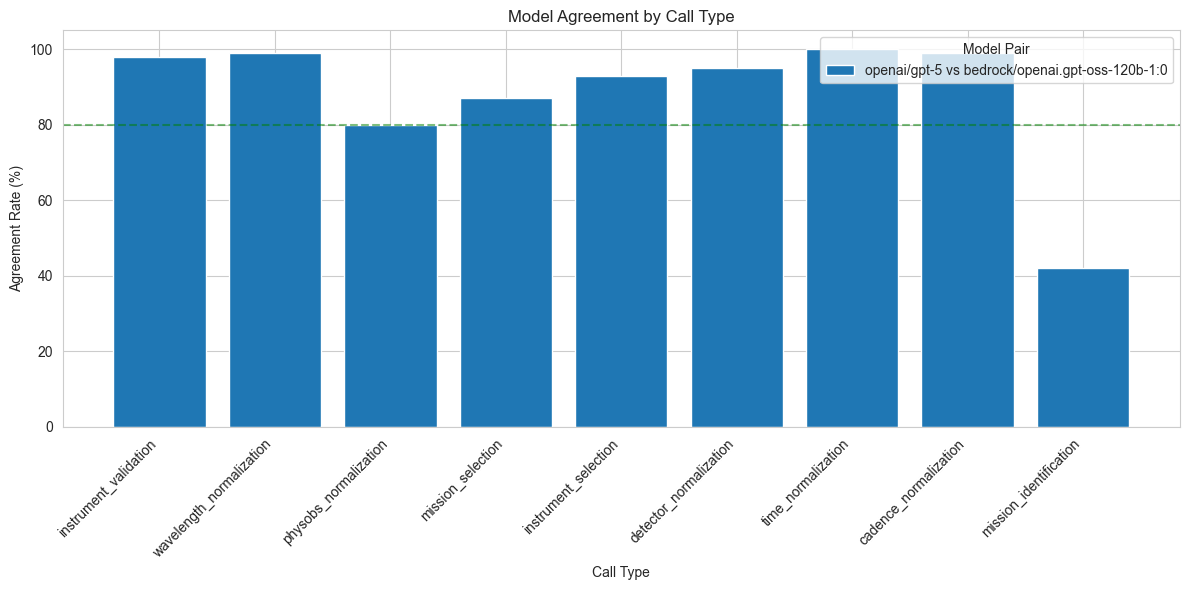

In [9]:
# Plot agreement rates
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for plotting
plot_data = []
for call_type in CALL_TYPES:
    for pair_name, result in agreement_results[call_type].items():
        if result:
            plot_data.append({
                'call_type': call_type,
                'pair': pair_name,
                'agreement': result['agreement_rate']
            })

if plot_data:
    df_plot = pd.DataFrame(plot_data)
    
    # Create grouped bar chart
    pairs = df_plot['pair'].unique()
    x = range(len(CALL_TYPES))
    width = 0.8 / len(pairs)
    
    for i, pair in enumerate(pairs):
        pair_data = df_plot[df_plot['pair'] == pair]
        agreements = [pair_data[pair_data['call_type'] == ct]['agreement'].values[0] 
                      if ct in pair_data['call_type'].values else 0 
                      for ct in CALL_TYPES]
        ax.bar([xi + i * width for xi in x], agreements, width, label=pair)
    
    ax.set_xlabel('Call Type')
    ax.set_ylabel('Agreement Rate (%)')
    ax.set_title('Model Agreement by Call Type')
    ax.set_xticks([xi + width * (len(pairs) - 1) / 2 for xi in x])
    ax.set_xticklabels(CALL_TYPES, rotation=45, ha='right')
    ax.legend(title='Model Pair')
    ax.axhline(y=80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
    ax.set_ylim(0, 105)
    
    plt.tight_layout()
    plt.show()
else:
    print("No data to plot - run experiments first")

## 7. Review Disagreements

Drill into specific cases where models disagree.

In [10]:
# Configuration for disagreement review
REVIEW_CALL_TYPE = 'instrument_validation'  # Change this
REVIEW_PAIR = list(model_pairs)[0] if model_pairs else None  # First model pair

if REVIEW_PAIR:
    pair_name = f"{REVIEW_PAIR[0]} vs {REVIEW_PAIR[1]}"
    result = agreement_results.get(REVIEW_CALL_TYPE, {}).get(pair_name)
    
    if result and result['disagreements']:
        print(f"\n{'='*80}")
        print(f"DISAGREEMENTS: {REVIEW_CALL_TYPE}")
        print(f"Models: {pair_name}")
        print(f"Agreement: {result['agreement_rate']:.1f}% ({result['agree']}/{result['total']})")
        print(f"Total Disagreements: {len(result['disagreements'])}")
        print(f"{'='*80}\n")
        
        # Show first 5 disagreements
        for i, case in enumerate(result['disagreements'][:5], 1):
            print(f"Case {i}: {case['case_id']}")
            print(f"  {REVIEW_PAIR[0]}: {case['model1_response']}")
            print(f"  {REVIEW_PAIR[1]}: {case['model2_response']}")
            print()
    elif result:
        print(f"\u2705 No disagreements for {REVIEW_CALL_TYPE} / {pair_name}")
    else:
        print(f"\u274c No results for {REVIEW_CALL_TYPE} / {pair_name}")
else:
    print("No model pairs configured")


DISAGREEMENTS: instrument_validation
Models: openai/gpt-5 vs bedrock/openai.gpt-oss-120b-1:0
Agreement: 98.0% (98/100)
Total Disagreements: 2

Case 1: 8303268e-a8c3-4188-81b2-2f9d80e175bf
  openai/gpt-5: invalid
  bedrock/openai.gpt-oss-120b-1:0: valid

Case 2: fab63e6f-a9f4-4e77-85c4-91274198bd45
  openai/gpt-5: valid
  bedrock/openai.gpt-oss-120b-1:0: invalid



In [11]:
# Detailed view of a specific disagreement case
CASE_INDEX = 0  # Change this to inspect different cases

if REVIEW_PAIR:
    pair_name = f"{REVIEW_PAIR[0]} vs {REVIEW_PAIR[1]}"
    result = agreement_results.get(REVIEW_CALL_TYPE, {}).get(pair_name)
    
    if result and len(result['disagreements']) > CASE_INDEX:
        case = result['disagreements'][CASE_INDEX]
        
        print(f"\n{'='*80}")
        print(f"DETAILED CASE: {case['case_id']}")
        print(f"{'='*80}")
        
        print(f"\n{REVIEW_PAIR[0]} Response:")
        print(f"  Parsed: {case['model1_response']}")
        print(f"  Raw: {case['model1_raw']}...")
        
        print(f"\n{REVIEW_PAIR[1]} Response:")
        print(f"  Parsed: {case['model2_response']}")
        print(f"  Raw: {case['model2_raw']}...")
    else:
        print(f"No case at index {CASE_INDEX}")


DETAILED CASE: 8303268e-a8c3-4188-81b2-2f9d80e175bf

openai/gpt-5 Response:
  Parsed: invalid
  Raw: VALIDATION ANALYSIS:
- Name/Type alignment: The description cites “CANOPUS and Greenland magnetometer networks” (networks of magnetometers); the proposed match is a single ground magnetometer at Summi...

bedrock/openai.gpt-oss-120b-1:0 Response:
  Parsed: valid
  Raw: VALIDATION ANALYSIS:
- Name/Type alignment: The original description refers to magnetometer networks (CANOPUS and Greenland). The proposed match is a ground‑based magnetometer instrument. The type (ma...


## Summary

This notebook demonstrated:
1. \u2705 Configuring models and call types for comparison
2. \u2705 Running experiments for each model on shared inputs
3. \u2705 Calculating pairwise agreement rates
4. \u2705 Reviewing specific disagreement cases

**Next Steps:**
- Add more models to MODELS list
- Investigate low-agreement call types
- Compare with self-consistency results